In [35]:
# Esame 654AA - a.a. 2025/2026
# Studenti: Leonardo Celati, Samuele Taviano
# Matricole: 660185, ?

<h1>Monk Datasets SVM</h1>
<p>Exploring the three monk datasets with SVM Classifier.</p>
<hr/>

In [36]:
import importlib
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score, cross_val_predict
import monk_common as mc
import svm_common as sc
import cross_common as cr

<h2>Exploring Datasets</h2>
<hr/>

In [37]:
# Note: The regularization parameter C is explored on a logarithmic scale over four orders of magnitude,
# from strong (0.1) to weak regularization (100), following standard practice for SVM hyperparameter tuning.
param_grid_default = [
    {  # linear
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100],
    },
    {  # poly
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.1, 1],
        "model__degree": [2, 3, 4],
    },
    {  # sigmoid
        "model__kernel": ["sigmoid"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.1, 1]
    },
    {  # rbf
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", 0.1, 1]
    },
]

# We only test SVC
pipe_default = Pipeline(steps=[
    ("model", SVC())
])

# Of all parameters 'shuffle' is quite relevant because the TR set is small
# We have preferred StratifiedKFold as it preserves class balance during folding (optimal in small dataset)
cv_default = cr.common_fold_strategy(stratified=True)


<h3>Monk 1</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [38]:
monk_1_TR_orig, monk_1_TS_orig = mc.load_set(1)
X_tr_1, y_tr_1 = mc.split_and_prepare_dataset(monk_1_TR_orig)
X_ts_1, y_ts_1 = mc.split_and_prepare_dataset(monk_1_TS_orig)
mc.dataset_introspection(monk_1_TR_orig, monk_1_TS_orig)

,Property,Training,Test
0,Number of samples,124,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 62","class 0 = 216, class 1 = 216"


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [39]:
scoring_1 = "accuracy"

# Perform a grid search
gs_1 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = scoring_1,
    n_jobs = -1 # use all available cores
)

gs_1.fit(X_tr_1, y_tr_1)
best_estimator_1 = gs_1.best_estimator_
model_1, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_1)
cr.grid_introspection(gs_1)


Total model explored: 64
Best params: {'model__C': 1, 'model__degree': 2, 'model__gamma': 1, 'model__kernel': 'poly'}
Best score: 1.0
Best model: Pipeline(steps=[('model', SVC(C=1, degree=2, gamma=1, kernel='poly'))])


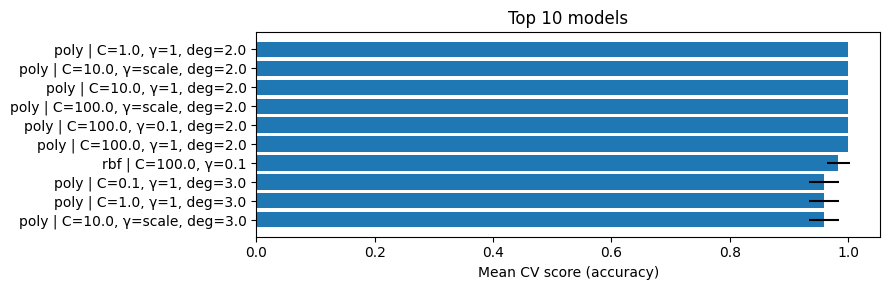

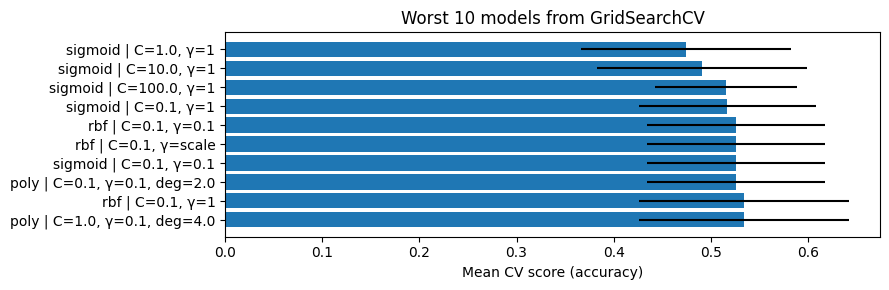

In [40]:
cr.plot_top_models(gs_1.cv_results_, label_row=sc.label_row,scoring_name=scoring_1)

<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [41]:
cv_predictions_1 = cross_val_predict(
    best_estimator_1,
    X_tr_1, y_tr_1,
    cv=cv_default
)

print(classification_report(y_tr_1, cv_predictions_1, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        62
           1       1.00      1.00      1.00        62

    accuracy                           1.00       124
   macro avg       1.00      1.00      1.00       124
weighted avg       1.00      1.00      1.00       124



<h5>Training Accuracy Comparison</h5>
<p>The selected model is evaluated by comparing its training accuracy with the mean and standard deviation of the cross-validation accuracy. This comparison provides insights into the generalization capability of the model and helps identify potential overfitting or underfitting phenomena.</p>

In [42]:
# Train score
train_score = best_estimator_1.score(X_tr_1, y_tr_1)

# CV score
cv_scores = cross_val_score(
    best_estimator_1, X_tr_1, y_tr_1,
    cv=cv_default, scoring=scoring_1
)

print(f"Train: {train_score:.3f}")
print(f"CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Train: 1.000
CV:    1.000 ± 0.000


<h5>Stability of cross-validation estimates</h5>
<p>To assess the robustness of the selected model, cross-validation was repeated using different random seeds for the data shuffling process. This allows evaluating the sensitivity of the estimated performance to different data partitions and provides an indication of the stability of the model under varying training/validation splits.</p>

In [43]:
cr.assess_sklearn_cv_robustness(cv_default, best_estimator_1, X_tr_1, y_tr_1, scoring=scoring_1)

seed: 10 - mean 1.000 ± 0.000
seed: 20 - mean 1.000 ± 0.000
seed: 30 - mean 1.000 ± 0.000
seed: 40 - mean 0.992 ± 0.017
seed: 50 - mean 1.000 ± 0.000


<h5>Features importance</h5>
<p>Computing features importance. Based on the rule used to build dataset <code>(a1 = a2) or (a5 = 1)</code>
we expect predominance of a1, a2 and a5.
</p>

In [44]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_estimator_1, X_tr_1, y_tr_1, scoring=scoring_1
)

print(comp_attr)

    SV_freq_max  Perm_importance_sum
a2     0.342466             0.326613
a1     0.369863             0.325403
a5     0.287671             0.244355
a6     0.561644             0.000000
a3     0.520548             0.000000
a4     0.383562             0.000000


<h5>Bias Variance Introspection</h5>
<p>Monitor bias - variance. We expect that a high error impacts on performance, which are measured in accuracy.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independently from the data size. The model is able to interpolate the function even with little data. The model has therefore very low bias.</li>
<li>Variance: The cross-validation accuracy shows a consistent gap with respect to the training accuracy for small training set sizes, indicating a high-variance regime. However, this gap progressively decreases as more data are used, and variance is effectively resolved for larger training sets.</li>
<li>Noise: monk 1 dataset is known to be noise free</li>
</ul>

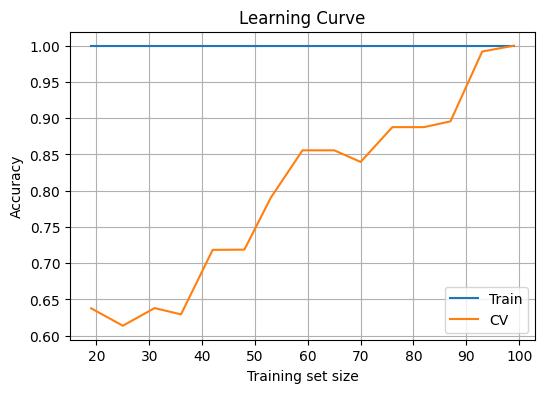

In [45]:
sc.plot_learning_curve_svm(best_estimator_1, X_tr_1, y_tr_1, cv_default)

<h4>Test predictions</h4>

In [46]:
test_predictions_1 = best_estimator_1.predict(X_ts_1)
test_accuracy_1 = best_estimator_1.score(X_ts_1, y_ts_1)

print(classification_report(y_ts_1, test_predictions_1, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       216
           1       1.00      1.00      1.00       216

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432



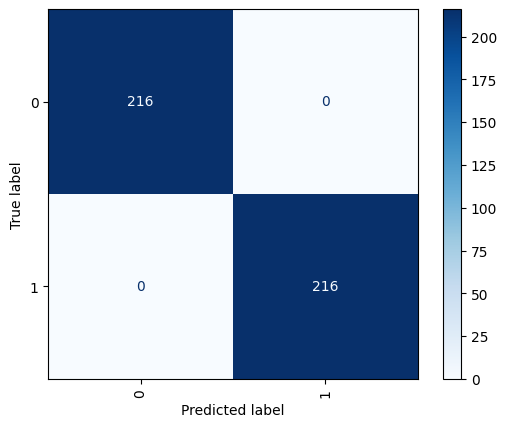

In [47]:
ConfusionMatrixDisplay.from_predictions(y_ts_1, test_predictions_1, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 2</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [48]:
monk_2_TR_orig, monk_2_TS_orig = mc.load_set(2)
X_tr_2, y_tr_2 = mc.split_and_prepare_dataset(monk_2_TR_orig)
X_ts_2, y_ts_2 = mc.split_and_prepare_dataset(monk_2_TS_orig)
mc.dataset_introspection(monk_2_TR_orig, monk_2_TS_orig)

,Property,Training,Test
0,Number of samples,169,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 105, class 1 = 64","class 0 = 290, class 1 = 142"


<h4>Model Selection</h4>
<p>Finding the best model with GridSearchCV.</p>

In [49]:
scoring_2 = cr.common_scoring("bacc") # <-- because the training set shows an unbalanced scenario
gs_2 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = scoring_2,
)

gs_2.fit(X_tr_2, y_tr_2)
best_estimator_2 = gs_2.best_estimator_
model_2, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_2)
cr.grid_introspection(gs_2)

Total model explored: 64
Best params: {'model__C': 10, 'model__degree': 2, 'model__gamma': 1, 'model__kernel': 'poly'}
Best score: 0.9223443223443223
Best model: Pipeline(steps=[('model', SVC(C=10, degree=2, gamma=1, kernel='poly'))])


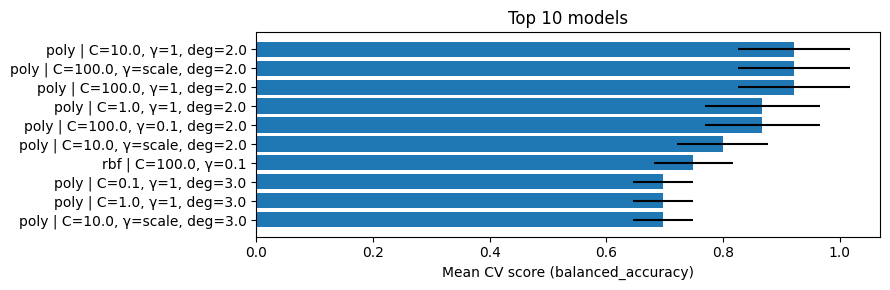

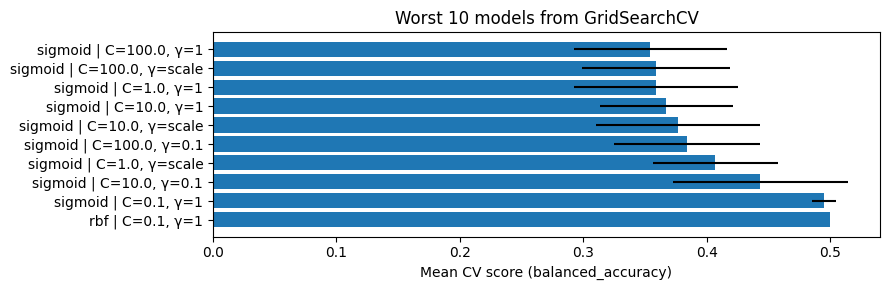

In [50]:
cr.plot_top_models(gs_2.cv_results_, label_row=sc.label_row,scoring_name=scoring_2)

<h4>Model Assesment</h4>
<p>Collecting various metrics for model assesment.</p>

In [51]:
cv_predictions_2 = cross_val_predict(
    best_estimator_2,
    X_tr_2, y_tr_2,
    cv=cv_default
)

print(classification_report(y_tr_2, cv_predictions_2, zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94       105
           1       0.92      0.89      0.90        64

    accuracy                           0.93       169
   macro avg       0.93      0.92      0.92       169
weighted avg       0.93      0.93      0.93       169



<h5>Training Accuracy Comparison</h5>
<p>The selected model is evaluated by comparing its training accuracy with the mean and standard deviation of the cross-validation accuracy. This comparison provides insights into the generalization capability of the model and helps identify potential overfitting or underfitting phenomena.</p>

In [52]:
# Train score
train_score = best_estimator_2.score(X_tr_2, y_tr_2)

# CV score
cv_scores = cross_val_score(
    best_estimator_2, X_tr_2, y_tr_2,
    cv=cv_default, scoring=scoring_2
)

print(f"Train: {train_score:.3f}")
print(f"CV:    {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")


Train: 1.000
CV:    0.922 ± 0.096


<h5>Stability of cross-validation estimates</h5>
<p>To assess the robustness of the selected model, cross-validation was repeated using different random seeds for the data shuffling process. This allows evaluating the sensitivity of the estimated performance to different data partitions and provides an indication of the stability of the model under varying training/validation splits.</p>

In [53]:
cr.assess_sklearn_cv_robustness(cv_default, best_estimator_2, X_tr_2, y_tr_2, scoring=scoring_2)

seed: 10 - mean 0.837 ± 0.107
seed: 20 - mean 0.961 ± 0.067
seed: 30 - mean 0.869 ± 0.078
seed: 40 - mean 0.838 ± 0.070
seed: 50 - mean 0.929 ± 0.074


<h5>Features importance</h5>
<p>Computing features importance. Based on the rule used to build dataset <code>(EXACTLY TWO of {a1 = 1, a2 = 1, a3 = 1, a4 = 1, a5 = 1, a6 = 1}</code>
we expect an almost equal distribution of predominance of all attributes.
</p>

In [54]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_estimator_2, X_tr_2, y_tr_2, scoring=scoring_2
)

print(comp_attr)

    SV_freq_max  Perm_importance_sum
a3     0.540984             0.373895
a6     0.524590             0.372094
a1     0.352459             0.349159
a5     0.319672             0.342299
a4     0.368852             0.335982
a2     0.409836             0.334483


<h5>Bias Variance Introspection</h5>
<p>Monitor bias - variance. We expect that a high error impacts on performance, which are measured in accuracy.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independently from the data size. The model is able to interpolate the function even with little data. The model has therefore very low bias.</li>
<li>Variance: the cv shows a consistent gap when compared with train curve. The gap is however progressively reduced by using more data, the model is therefore subjected to high variance. Also, the fact that the gap is never closed means that the model suffers from an amount of variance.</li>
<li>Noise: monk 1 dataset is known to be noise free</li>
</ul>

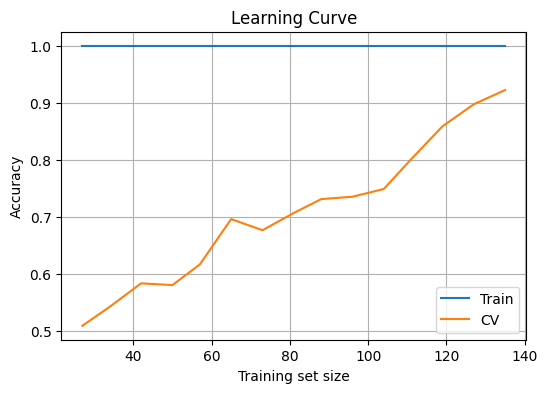

In [55]:
sc.plot_learning_curve_svm(best_estimator_2, X_tr_2, y_tr_2, cv_default, scoring=scoring_2)

<h4>Test predictions</h4>

In [56]:
test_predictions_2 = best_estimator_2.predict(X_ts_2)
test_accuracy_2 = best_estimator_2.score(X_ts_2, y_ts_2)

In [57]:
print(classification_report(y_ts_2, test_predictions_2, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       290
           1       1.00      1.00      1.00       142

    accuracy                           1.00       432
   macro avg       1.00      1.00      1.00       432
weighted avg       1.00      1.00      1.00       432



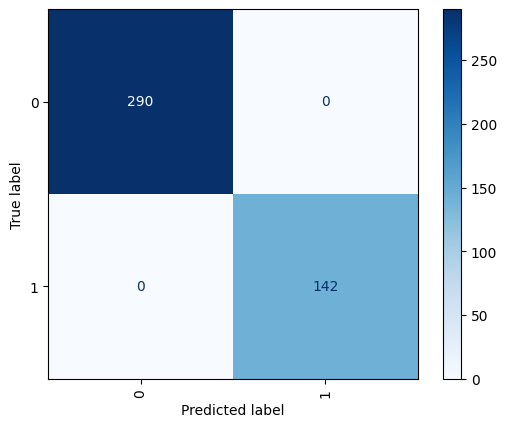

In [58]:
ConfusionMatrixDisplay.from_predictions(y_ts_2, test_predictions_2, xticks_rotation='vertical', cmap='Blues');

<hr/>

<h3>Monk 3</h3>

<h4>Data Loading</h4>
<p>Load and prepare data</p>

In [59]:
monk_3_TR_orig, monk_3_TS_orig = mc.load_set(3)
X_tr_3, y_tr_3 = mc.split_and_prepare_dataset(monk_3_TR_orig)
X_ts_3, y_ts_3 = mc.split_and_prepare_dataset(monk_3_TS_orig)
mc.dataset_introspection(monk_3_TR_orig, monk_3_TS_orig)

,Property,Training,Test
0,Number of samples,122,432
1,Number of features,6,6
2,Class values,"[0, 1]","[0, 1]"
3,Class balance,"class 0 = 62, class 1 = 60","class 0 = 204, class 1 = 228"


In [60]:
scoring_3 = "accuracy"

gs_3 = GridSearchCV(
    estimator = pipe_default,
    param_grid = param_grid_default,
    cv = cv_default,
    scoring = scoring_3,
)


gs_3.fit(X_tr_3, y_tr_3)
best_estimator_3 = gs_3.best_estimator_# Y_train shape: (n_samples, 4)
model_3, best_params = cr.extract_best_pipeline_metrics_from_grid(gs_3)
cr.grid_introspection(gs_3)

Total model explored: 64
Best params: {'model__C': 10, 'model__degree': 3, 'model__gamma': 0.1, 'model__kernel': 'poly'}
Best score: 0.9426666666666665
Best model: Pipeline(steps=[('model', SVC(C=10, gamma=0.1, kernel='poly'))])


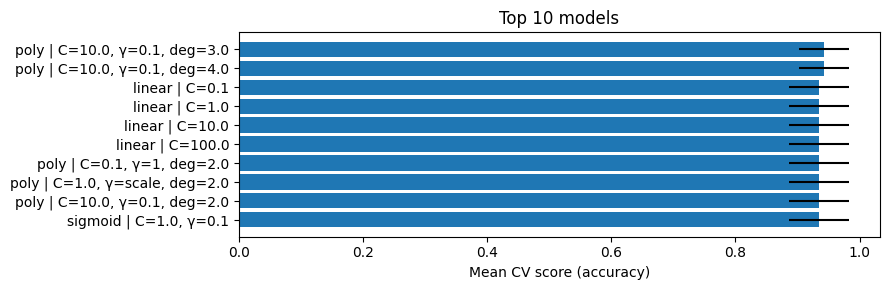

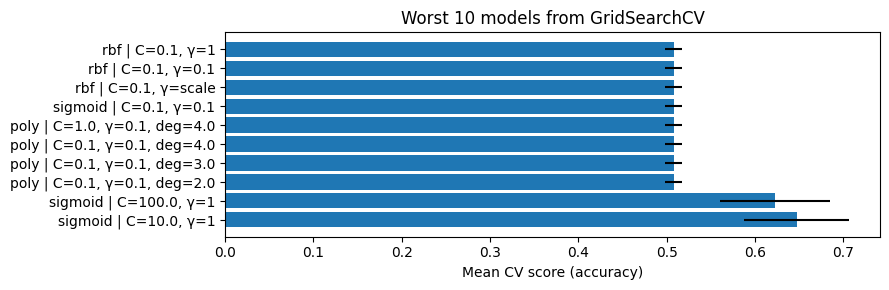

In [61]:
cr.plot_top_models(gs_3.cv_results_, label_row=sc.label_row,scoring_name=scoring_3)

<p>Computing features importance. Based on the rule used to build dataset <code>(a5 = 3 and a4 = 1) or (a5 = 4 and a2 = 3)</code>
we expect predominance of a5, a4, a2
</p>

In [62]:
sv_freq, perm_imp, comp_attr = sc.compare_svfreq_vs_permutation(
    best_estimator_3, X_tr_3, y_tr_3, scoring=scoring_3
)

print("Frequency vs importance (a1..a6):")
print(comp_attr)

Frequency vs importance (a1..a6):
    SV_freq_max  Perm_importance_sum
a5     0.315789             0.219262
a2     0.381579             0.183607
a4     0.355263             0.020492
a1     0.355263             0.012295
a3     0.592105             0.004918
a6     0.552632            -0.001639


<h4>Model Assessment</h4>
<p>Collecting various metrics for model assesment.</p>

In [63]:
cv_predictions_3 = cross_val_predict(
    best_estimator_3,
    X_tr_3, y_tr_3,
    cv=cv_default
)

print(classification_report(y_tr_3, cv_predictions_3, zero_division=0))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        62
           1       0.93      0.95      0.94        60

    accuracy                           0.94       122
   macro avg       0.94      0.94      0.94       122
weighted avg       0.94      0.94      0.94       122



<h5>Training Accuracy Comparison</h5>
<p>The selected model is evaluated by comparing its training accuracy with the mean and standard deviation of the cross-validation accuracy. This comparison provides insights into the generalization capability of the model and helps identify potential overfitting or underfitting phenomena.</p>

In [64]:
# Train score
train_score_3 = best_estimator_3.score(X_tr_3, y_tr_3)

# CV score (stessa CV della GridSearch!)
cv_scores_3 = cross_val_score(
    best_estimator_3, X_tr_3, y_tr_3,
    cv=cv_default, scoring=scoring_3
)

print(f"Train: {train_score_3:.3f}")
print(f"CV:    {cv_scores_3.mean():.3f} ± {cv_scores_3.std():.3f}")


Train: 0.959
CV:    0.943 ± 0.041


<h5>Stability of cross-validation estimates</h5>
<p>To assess the robustness of the selected model, cross-validation was repeated using different random seeds for the data shuffling process. This allows evaluating the sensitivity of the estimated performance to different data partitions and provides an indication of the stability of the model under varying training/validation splits.</p>

In [65]:
cr.assess_sklearn_cv_robustness(cv_default, best_estimator_3, X_tr_2, y_tr_2, scoring=scoring_3)

seed: 10 - mean 0.603 ± 0.043
seed: 20 - mean 0.627 ± 0.063
seed: 30 - mean 0.627 ± 0.038
seed: 40 - mean 0.598 ± 0.058
seed: 50 - mean 0.604 ± 0.058


<h5>Features importance</h5>
<p>Computing features importance. Based on the rule used to build dataset <code>(a5 = 3 and a4 = 1) or (a5 = 4 and a2 = 3)</code>
we expect an almost equal distribution of predominance of a5, a4 and a2 attributes.
</p>

In [66]:
cr.assess_cv_robustness(cv_default, best_estimator_3, X_tr_3, y_tr_3, scoring=scoring_3)

seed: 10 - mean 0.927 ± 0.029
seed: 20 - mean 0.885 ± 0.061
seed: 30 - mean 0.885 ± 0.067
seed: 40 - mean 0.926 ± 0.016
seed: 50 - mean 0.917 ± 0.046


<h5>Bias Variance Introspection</h5>
<p>Applying various techniques to monitor bias - variance.</p>
$$\mathbb{E}_{P}[(y - h(x))^2] = \text{Bias}^2 + \text{Variance} + \text{Noise}$$
<p>
<ul>
<li>Bias: the train accuracy is stable to 1 independent from the data size so the model has bias 0</li>
<li>Variance: the cv shows an increase in accuracy with more data, the model is therefore subjected to high variance</li>
<li>Noise: monk 3 dataset is known to have noise</li>
</ul>

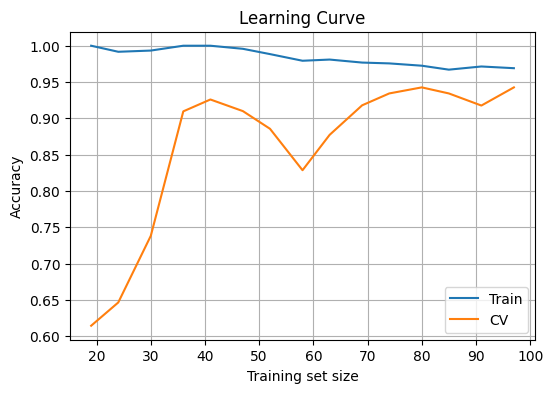

In [67]:
sc.plot_learning_curve_svm(best_estimator_3, X_tr_3, y_tr_3, cv_default)

<h4>Test predictions</h4>

In [68]:
test_predictions_3 = best_estimator_3.predict(X_ts_3)
test_accuracy_3 = best_estimator_3.score(X_ts_3, y_ts_3)

In [69]:
print(classification_report(y_ts_3, test_predictions_3, zero_division=0))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       204
           1       1.00      0.97      0.98       228

    accuracy                           0.98       432
   macro avg       0.98      0.98      0.98       432
weighted avg       0.98      0.98      0.98       432



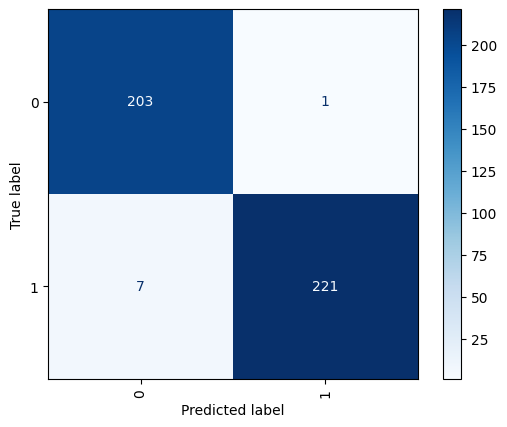

In [70]:
ConfusionMatrixDisplay.from_predictions(y_ts_3, test_predictions_3, xticks_rotation='vertical', cmap='Blues');